# Context Classifier

## Self-Supervised Contrastive Learning

### Setup

In [103]:
import os
from pathlib import Path
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("TF Version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))

TF Version: 2.10.1
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Data Load & Initial Preprocessing

In [104]:
# data_dirs = ['data/sol/raw', 'data/mtga/raw', 'data/mtgl/raw', 'data/hs/raw']
data_dirs = ['data_aug/sol', 'data_aug/mtga', 'data_aug/mtgl', 'data_aug/hs']

images = []
labels = []

IMG_SIZE = 128

# Load images and create labels
total_files = 0
for data_dir in data_dirs:
    total_files += len(list(Path(data_dir).glob('*.png')) + list(Path(data_dir).glob('*.jpeg')) + list(Path(data_dir).glob('*.jpg')))

current_file = 0
for label_idx, data_dir in enumerate(data_dirs):
    image_files = list(Path(data_dir).glob('*.png')) + list(Path(data_dir).glob('*.jpeg')) + list(Path(data_dir).glob('*.jpg'))
    for img_path in image_files:
        current_file += 1
        if current_file % 50 == 0:
            print(f'Processing image {current_file}/{total_files}')
            
        img = tf.io.read_file(str(img_path))
        img = tf.image.decode_image(img, channels=3)
        
        # Resize maintaining aspect ratio
        shape = tf.shape(img)
        h = tf.cast(shape[0], tf.float32)
        w = tf.cast(shape[1], tf.float32)
        scale = IMG_SIZE / tf.maximum(h, w)
        new_h = tf.cast(h * scale, tf.int32)
        new_w = tf.cast(w * scale, tf.int32)
        img = tf.image.resize(img, [new_h, new_w])
        
        # Pad to square
        img = tf.image.resize_with_crop_or_pad(img, IMG_SIZE, IMG_SIZE)
        
        images.append(img)
        labels.append(label_idx)

# Label mapping
label_mapping = {
    0: 'sol',
    1: 'mtga',
    2: 'mtgl',
    3: 'hs'
}

print("\nLabel mapping:")
for num, name in label_mapping.items():
    print(f"Class {num}: {name}")

print("Done")

Processing image 50/5492
Processing image 100/5492
Processing image 150/5492
Processing image 200/5492
Processing image 250/5492
Processing image 300/5492
Processing image 350/5492
Processing image 400/5492
Processing image 450/5492
Processing image 500/5492
Processing image 550/5492
Processing image 600/5492
Processing image 650/5492
Processing image 700/5492
Processing image 750/5492
Processing image 800/5492
Processing image 850/5492
Processing image 900/5492
Processing image 950/5492
Processing image 1000/5492
Processing image 1050/5492
Processing image 1100/5492
Processing image 1150/5492
Processing image 1200/5492
Processing image 1250/5492
Processing image 1300/5492
Processing image 1350/5492
Processing image 1400/5492
Processing image 1450/5492
Processing image 1500/5492
Processing image 1550/5492
Processing image 1600/5492
Processing image 1650/5492
Processing image 1700/5492
Processing image 1750/5492
Processing image 1800/5492
Processing image 1850/5492
Processing image 1900

(5492, 128, 128, 3)
(5492,)


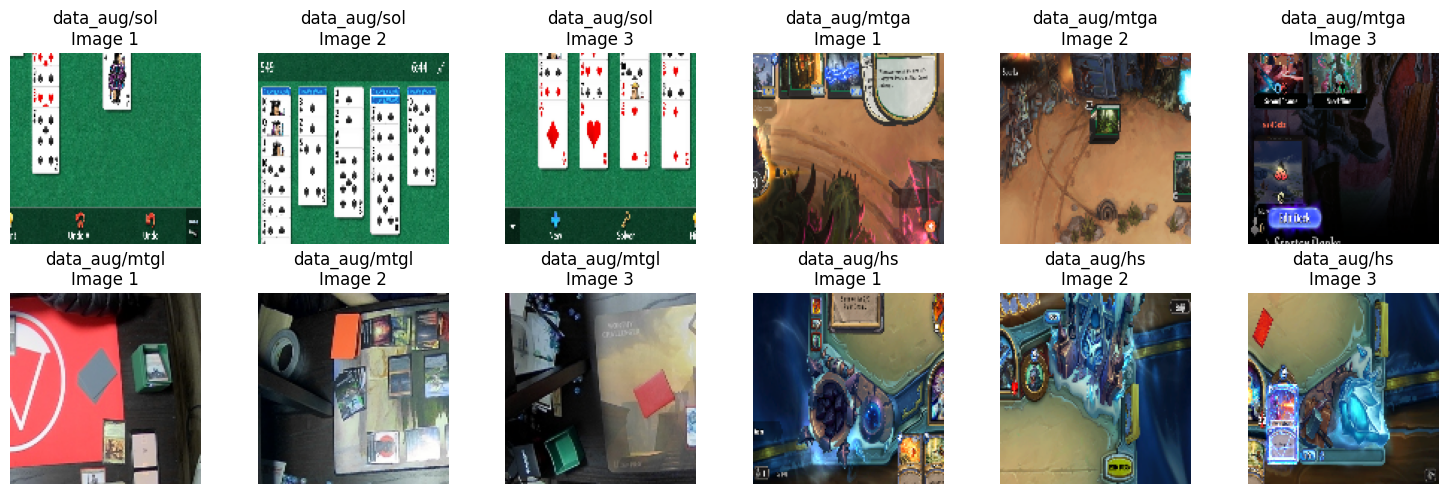

In [105]:
# Convert lists to numpy arrays
images = np.array(images)
labels = np.array(labels)

print(images.shape)
print(labels.shape)

# Plot random images from each class
plt.figure(figsize=(15, 5))
for i, label in enumerate(np.unique(labels)):
    indices = np.where(labels == label)[0]
    sample_indices = np.random.choice(indices, size=3, replace=False)
    
    for j, idx in enumerate(sample_indices):
        plt.subplot(2, 6, i*3 + j + 1)
        plt.imshow(images[idx].astype('uint8'))
        plt.title(f'{data_dirs[i]}\nImage {j+1}')
        plt.axis('off')

plt.tight_layout()
plt.show()

# Convert to TensorFlow dataset
dataset = tf.data.Dataset.from_tensor_slices((images, labels))

In [106]:
# Count number of images per class
unique_labels, counts = np.unique(labels, return_counts=True)

print("\nClass distribution:")
for label, count in zip(data_dirs, counts):
    print(f"{label}: {count} images")


Class distribution:
data_aug/sol: 1748 images
data_aug/mtga: 2256 images
data_aug/mtgl: 1364 images
data_aug/hs: 124 images


In [107]:
# Convert to tensors
images = tf.stack(images)
labels = tf.convert_to_tensor(labels)

# Create dataset
dataset = tf.data.Dataset.from_tensor_slices((images, labels))

# Shuffle the dataset
dataset = dataset.shuffle(buffer_size=len(images))

# Calculate split sizes (80% train, 20% test)
train_size = int(0.8 * len(images))
test_size = len(images) - train_size

# Split into train and test
train_ds = dataset.take(train_size)
val_ds = dataset.skip(train_size)

print(f"Total images: {len(images)}")
print(f"Training images: {train_size}")
print(f"Test images: {test_size}")

Total images: 5492
Training images: 4393
Test images: 1099


In [108]:
# Data Augmentation
def simclr_augment(image):
    image = tf.image.resize_with_crop_or_pad(image, IMG_SIZE + 4, IMG_SIZE + 4)
    image = tf.image.random_crop(image, size=[IMG_SIZE, IMG_SIZE, 3])
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.5)
    image = tf.image.random_contrast(image, 0.5, 1.5)
    image = tf.image.adjust_saturation(image, np.random.uniform(0.5, 1.5))
    image = tf.image.adjust_hue(image, np.random.uniform(-0.2, 0.2))
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image

def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def simclr_preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return (simclr_augment(image), simclr_augment(image)), label

In [109]:
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_contrastive_ds = (train_ds
    .map(simclr_preprocess, num_parallel_calls=AUTOTUNE)
    .shuffle(10000)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE))

# Encoder Model
def get_encoder():
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = tf.keras.layers.Conv2D(128, 3, padding='same')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dense(128)(x)
    return tf.keras.Model(inputs, x, name='encoder')

# Projection Head
def add_projection_head(encoder):
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    features = encoder(inputs)
    x = tf.keras.layers.Dense(128, activation='relu')(features)
    outputs = tf.keras.layers.Dense(64)(x)
    return tf.keras.Model(inputs, outputs, name='simclr_model')

# Contrastive Loss Function
def contrastive_loss(embeddings, temperature=0.5):
    embeddings = tf.math.l2_normalize(embeddings, axis=1)
    similarities = tf.matmul(embeddings, embeddings, transpose_b=True)
    batch_size = tf.shape(embeddings)[0] // 2
    labels = tf.range(batch_size)
    labels = tf.concat([labels, labels], axis=0)
    logits_mask = tf.linalg.set_diag(
        tf.ones_like(similarities), 
        tf.zeros_like(tf.linalg.diag_part(similarities))
    )
    logits = similarities / temperature
    logits = logits * logits_mask
    loss = tf.keras.losses.sparse_categorical_crossentropy(
        labels, 
        logits, 
        from_logits=True
    )
    return tf.reduce_mean(loss)


In [110]:
# Training Step
encoder = get_encoder()
simclr_model = add_projection_head(encoder)
optimizer = tf.keras.optimizers.Adam()

@tf.function
def train_step(x1, x2):
    with tf.GradientTape() as tape:
        z1 = simclr_model(x1, training=True)
        z2 = simclr_model(x2, training=True)
        embeddings = tf.concat([z1, z2], axis=0)
        loss = contrastive_loss(embeddings)
    gradients = tape.gradient(loss, simclr_model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, simclr_model.trainable_variables))
    return loss

# Training Loop
EPOCHS = 20
for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}/{EPOCHS}")
    for step, ((x1, x2), _) in enumerate(train_contrastive_ds):
        loss = train_step(x1, x2)
        if step % 10 == 0:
            print(f"Step {step}: Contrastive Loss = {loss.numpy():.4f}")


Epoch 1/20
Step 0: Contrastive Loss = 4.6175
Step 10: Contrastive Loss = 4.0389
Step 20: Contrastive Loss = 4.0506
Step 30: Contrastive Loss = 3.9592
Step 40: Contrastive Loss = 3.8816
Step 50: Contrastive Loss = 3.9017
Step 60: Contrastive Loss = 3.9512
Step 70: Contrastive Loss = 3.9754
Step 80: Contrastive Loss = 3.8726
Step 90: Contrastive Loss = 3.8181
Step 100: Contrastive Loss = 3.7857
Step 110: Contrastive Loss = 3.8743
Step 120: Contrastive Loss = 3.7762
Step 130: Contrastive Loss = 3.7525
Epoch 2/20
Step 0: Contrastive Loss = 3.8199
Step 10: Contrastive Loss = 3.7841
Step 20: Contrastive Loss = 3.7617
Step 30: Contrastive Loss = 3.7082
Step 40: Contrastive Loss = 3.7768
Step 50: Contrastive Loss = 3.7523
Step 60: Contrastive Loss = 3.8576
Step 70: Contrastive Loss = 3.7612
Step 80: Contrastive Loss = 3.7318
Step 90: Contrastive Loss = 3.7629
Step 100: Contrastive Loss = 3.8024
Step 110: Contrastive Loss = 3.6879
Step 120: Contrastive Loss = 3.7977
Step 130: Contrastive Loss =

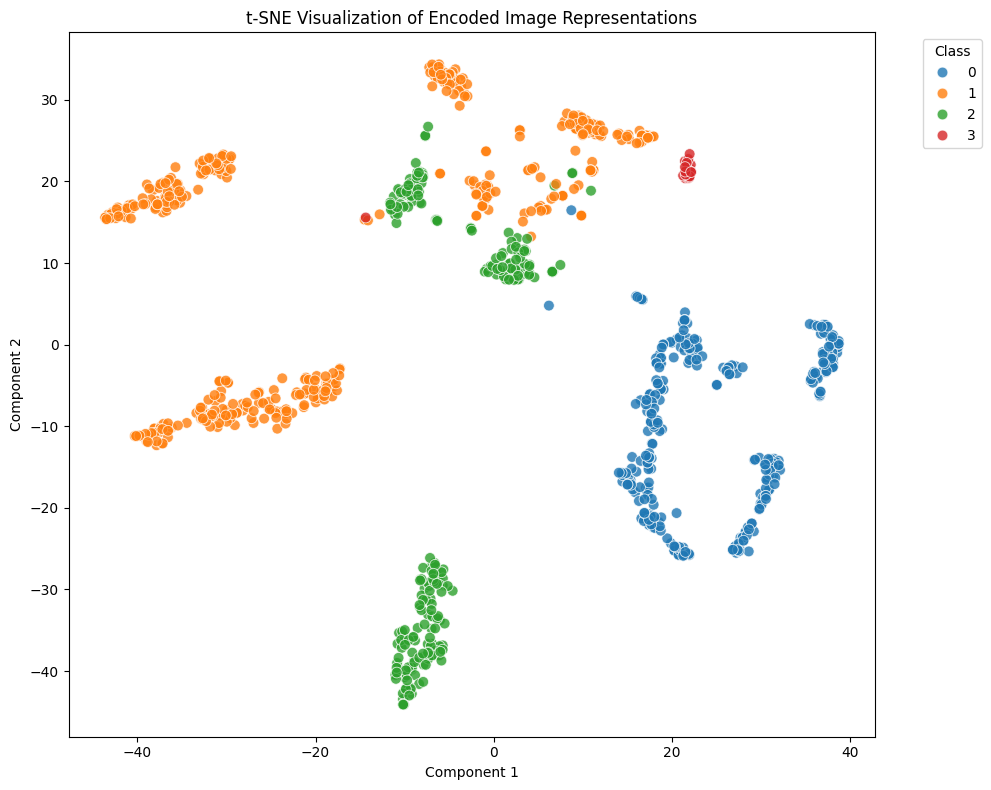

In [111]:
# Visualize Embeddings with t-SNE
val_subset = val_ds.take(1000).map(preprocess).batch(32)
all_embeddings = []
all_labels = []

for images, labels in val_subset:
    batch_embeddings = encoder(images, training=False).numpy()
    all_embeddings.append(batch_embeddings)
    all_labels.append(labels.numpy())

embeddings = np.concatenate(all_embeddings, axis=0)
labels = np.concatenate(all_labels, axis=0)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=embeddings_2d[:, 0], y=embeddings_2d[:, 1], hue=labels, palette='tab10', s=60, alpha=0.8)
plt.title("t-SNE Visualization of Encoded Image Representations")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [112]:
# Linear Evaluation
encoder.trainable = False

train_classifier_ds = (
    train_ds
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .shuffle(10000)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE))

val_classifier_ds = (
    val_ds
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(AUTOTUNE))

classifier = tf.keras.Sequential([
    encoder,
    # tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(64, activation='relu'),
    # tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(4, activation='softmax')
])

classifier.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

classifier.fit(train_classifier_ds, validation_data=val_classifier_ds, epochs=5)

val_loss, val_acc = classifier.evaluate(val_classifier_ds)
print("Validation Loss: ", val_loss, " Validation Accuracy: ", val_acc)

Epoch 1/5
138/138 [==============================] - 2s 14ms/step - loss: 0.2415 - accuracy: 0.9219 - val_loss: 0.0612 - val_accuracy: 0.9882
Epoch 2/5
138/138 [==============================] - 1s 10ms/step - loss: 0.0420 - accuracy: 0.9909 - val_loss: 0.0435 - val_accuracy: 0.9891
Epoch 3/5
138/138 [==============================] - 1s 9ms/step - loss: 0.0352 - accuracy: 0.9913 - val_loss: 0.0357 - val_accuracy: 0.9891
Epoch 4/5
138/138 [==============================] - 2s 10ms/step - loss: 0.0263 - accuracy: 0.9925 - val_loss: 0.0318 - val_accuracy: 0.9918
Epoch 5/5
35/35 [==============================] - 0s 7ms/step - loss: 0.0255 - accuracy: 0.9909
Validation Loss:  0.02548457495868206  Validation Accuracy:  0.9909008145332336


35/35 [==============================] - 0s 5ms/step
Validation Accuracy: 0.9909


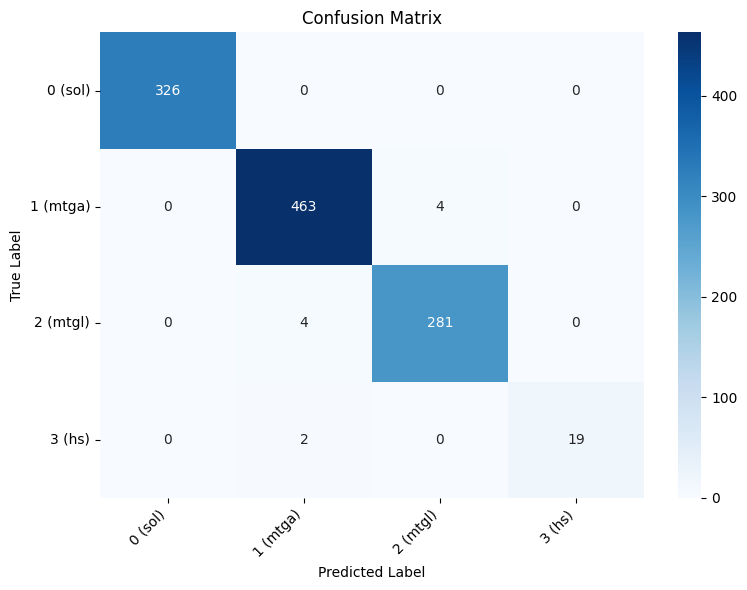

In [113]:
# Generate predictions and confusion matrix
val_predictions = classifier.predict(val_classifier_ds)
val_pred_classes = np.argmax(val_predictions, axis=1)
val_true_classes = np.concatenate([labels for _, labels in val_classifier_ds])

# Calculate accuracy
accuracy = np.mean(val_pred_classes == val_true_classes)
print(f"Validation Accuracy: {accuracy:.4f}")

cm = confusion_matrix(val_true_classes, val_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Add class labels to axes
tick_labels = [f'{i} ({label_mapping[i]})' for i in range(4)]
plt.xticks(np.arange(4) + 0.5, tick_labels, rotation=45, ha='right')
plt.yticks(np.arange(4) + 0.5, tick_labels, rotation=0)

plt.tight_layout()
plt.show()

In [114]:
classifier.save("models/context_classifier.h5")

# Supervised Contrastive Learning

In [115]:
def supcon_preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return ((simclr_augment(image), simclr_augment(image)), label)

supcon_ds = (
    train_ds
    .map(supcon_preprocess, num_parallel_calls=AUTOTUNE)
    .shuffle(10000)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

def supervised_contrastive_loss(features, labels, temperature=0.07):
    # Normalize embeddings
    features = tf.math.l2_normalize(features, axis=1)
    
    labels = tf.cast(labels, tf.int32)
    mask = tf.equal(tf.expand_dims(labels, 1), tf.expand_dims(labels, 0))
    
    logits = tf.divide(tf.matmul(features, tf.transpose(features)), temperature)
    logits_mask = tf.cast(~tf.eye(tf.shape(labels)[0], dtype=tf.bool), tf.float32)
    
    exp_logits = tf.exp(logits) * logits_mask
    log_prob = logits - tf.math.log(tf.reduce_sum(exp_logits, axis=1, keepdims=True) + 1e-9)
    
    mask = tf.cast(mask, tf.float32) * logits_mask
    mean_log_prob_pos = tf.reduce_sum(mask * log_prob, axis=1) / (tf.reduce_sum(mask, axis=1) + 1e-9)
    
    loss = -tf.reduce_mean(mean_log_prob_pos)
    return loss

In [116]:
encoder_sup = get_encoder()
supcon_model = add_projection_head(encoder_sup)
optimizer_sup = tf.keras.optimizers.Adam()

@tf.function
def supcon_train_step(x1, x2, labels):
    with tf.GradientTape() as tape:
        z1 = supcon_model(x1, training=True)
        z2 = supcon_model(x2, training=True)
        features = tf.concat([z1, z2], axis=0)
        labels_concat = tf.concat([labels, labels], axis=0)
        loss = supervised_contrastive_loss(features, labels_concat)
    grads = tape.gradient(loss, supcon_model.trainable_variables)
    optimizer_sup.apply_gradients(zip(grads, supcon_model.trainable_variables))
    return loss

# Training loop
for epoch in range(EPOCHS):
    print(f"[SupCon] Epoch {epoch+1}/{EPOCHS}")
    for step, ((x1, x2), labels_batch) in enumerate(supcon_ds):
        loss = supcon_train_step(x1, x2, labels_batch)
        if step % 10 == 0:
            print(f"Step {step}: SupCon Loss = {loss.numpy():.4f}")


[SupCon] Epoch 1/20
Step 0: SupCon Loss = 7.5473
Step 10: SupCon Loss = 3.7125
Step 20: SupCon Loss = 3.7251
Step 30: SupCon Loss = 3.5575
Step 40: SupCon Loss = 3.5344
Step 50: SupCon Loss = 3.7610
Step 60: SupCon Loss = 3.5093
Step 70: SupCon Loss = 3.4660
Step 80: SupCon Loss = 3.6063
Step 90: SupCon Loss = 3.5517
Step 100: SupCon Loss = 3.7562
Step 110: SupCon Loss = 3.5252
Step 120: SupCon Loss = 3.4775
Step 130: SupCon Loss = 3.6012
[SupCon] Epoch 2/20
Step 0: SupCon Loss = 3.9382
Step 10: SupCon Loss = 3.5247
Step 20: SupCon Loss = 3.5846
Step 30: SupCon Loss = 3.3212
Step 40: SupCon Loss = 3.2973
Step 50: SupCon Loss = 3.4049
Step 60: SupCon Loss = 3.6093
Step 70: SupCon Loss = 3.4851
Step 80: SupCon Loss = 3.3137
Step 90: SupCon Loss = 3.6369
Step 100: SupCon Loss = 3.4665
Step 110: SupCon Loss = 3.6502
Step 120: SupCon Loss = 3.5395
Step 130: SupCon Loss = 3.4215
[SupCon] Epoch 3/20
Step 0: SupCon Loss = 3.1892
Step 10: SupCon Loss = 3.6445
Step 20: SupCon Loss = 3.5568
Step 

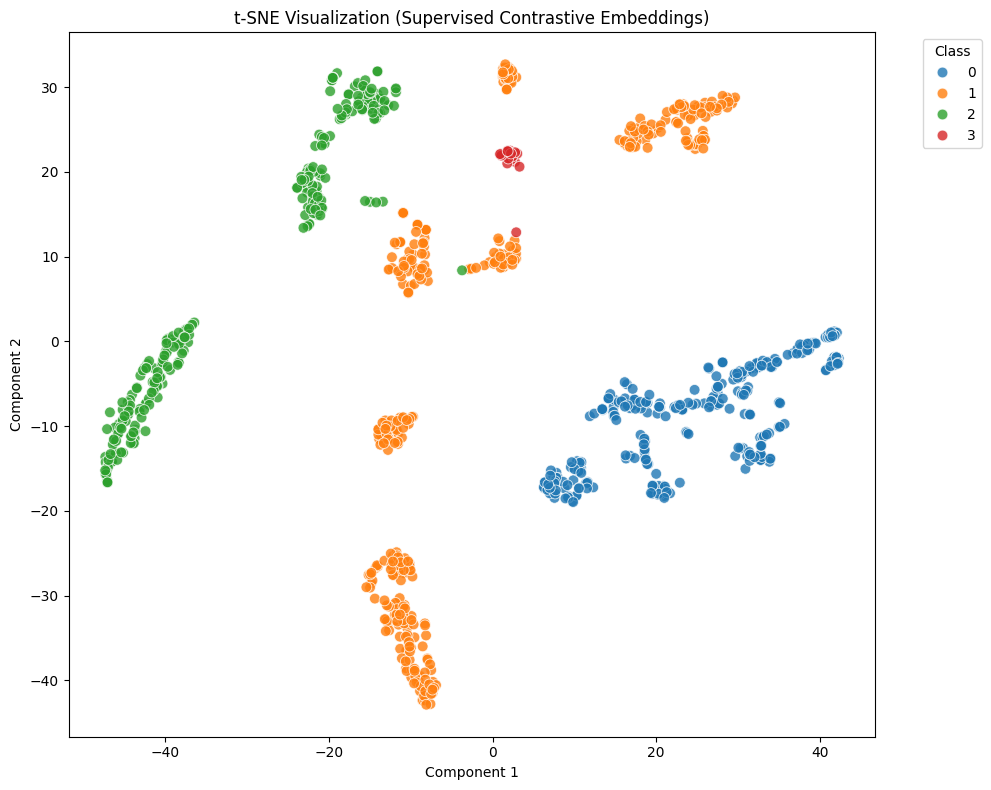

In [117]:
val_subset_sup = val_ds.take(1000).map(preprocess).batch(32)
all_embeddings_sup = []
all_labels_sup = []

for images, labels in val_subset_sup:
    batch_embeddings = encoder_sup(images, training=False).numpy()
    all_embeddings_sup.append(batch_embeddings)
    all_labels_sup.append(labels.numpy())

embeddings_sup = np.concatenate(all_embeddings_sup, axis=0)
labels_sup = np.concatenate(all_labels_sup, axis=0)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embeddings_2d_sup = tsne.fit_transform(embeddings_sup)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=embeddings_2d_sup[:, 0], y=embeddings_2d_sup[:, 1], hue=labels_sup, palette='tab10', s=60, alpha=0.8)
plt.title("t-SNE Visualization (Supervised Contrastive Embeddings)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [118]:
encoder_sup.trainable = False

classifier_sup = tf.keras.Sequential([
    encoder_sup,
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(4, activation='softmax')
])

classifier_sup.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

classifier_sup.fit(train_classifier_ds, validation_data=val_classifier_ds, epochs=5)

val_loss_sup, val_acc_sup = classifier_sup.evaluate(val_classifier_ds)
print("SupCon Validation Loss: ", val_loss_sup, " Validation Accuracy: ", val_acc_sup)

Epoch 1/5
138/138 [==============================] - 2s 12ms/step - loss: 0.2751 - accuracy: 0.9035 - val_loss: 0.0565 - val_accuracy: 0.9955
Epoch 2/5
138/138 [==============================] - 2s 11ms/step - loss: 0.0364 - accuracy: 0.9959 - val_loss: 0.0305 - val_accuracy: 0.9964
Epoch 3/5
138/138 [==============================] - 2s 11ms/step - loss: 0.0235 - accuracy: 0.9964 - val_loss: 0.0226 - val_accuracy: 0.9964
Epoch 4/5
138/138 [==============================] - 2s 10ms/step - loss: 0.0165 - accuracy: 0.9973 - val_loss: 0.0177 - val_accuracy: 0.9964
Epoch 5/5
35/35 [==============================] - 0s 9ms/step - loss: 0.0156 - accuracy: 0.9964
SupCon Validation Loss:  0.015617147088050842  Validation Accuracy:  0.9963603019714355


35/35 [==============================] - 0s 6ms/step
Validation Accuracy: 0.9964


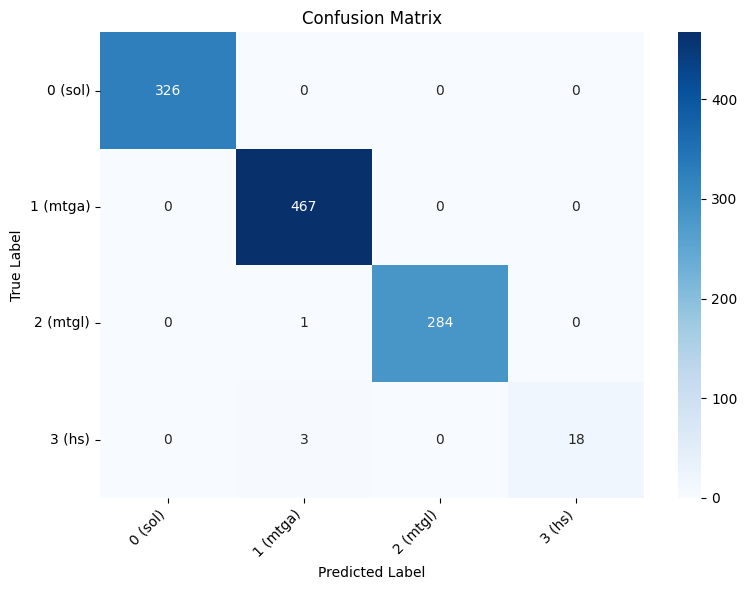

In [119]:
# Generate predictions and confusion matrix
val_predictions = classifier_sup.predict(val_classifier_ds)
val_pred_classes = np.argmax(val_predictions, axis=1)
val_true_classes = np.concatenate([labels for _, labels in val_classifier_ds])

# Calculate accuracy
accuracy = np.mean(val_pred_classes == val_true_classes)
print(f"Validation Accuracy: {accuracy:.4f}")

cm = confusion_matrix(val_true_classes, val_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Add class labels to axes
tick_labels = [f'{i} ({label_mapping[i]})' for i in range(4)]
plt.xticks(np.arange(4) + 0.5, tick_labels, rotation=45, ha='right')
plt.yticks(np.arange(4) + 0.5, tick_labels, rotation=0)

plt.tight_layout()
plt.show()